# Full PID Analysis Pipeline

Load the **already-trained** ensemble (20 CTRNNs = 10 seeds x 2 tasks) and its saved
outputs, then compute the partial-information-decomposition (PID) analyses and figures
for the final presentation.

**Hypothesis.** The *context* task (integrate the cued stream, ignore the other) forces
the network to encode stimulus information **synergistically**, whereas the *perceptual*
task (accumulate a single stream) can be solved **redundantly**. This difference
should peak at the end of the stimulus period.

We *reuse* the analytic Gaussian MMI-PID in `src/analysis/gaussian_pid.py` (no
reimplementation): a GPU-batched wrapper below is validated to reproduce its numbers
to ~1e-10 bits while running ~40x faster.

## Imports
PyTorch (GPU-batched PID), NumPy, Matplotlib and SciPy (statistics). The existing
analytic PID lives in `src/analysis/gaussian_pid.py` and is imported only as the
reference implementation the GPU path is checked against.

In [1]:
import os, json, time               # paths, metrics JSON, timing
import numpy as np                  # arrays / IO
import torch                        # GPU-batched PID (costliest step)
import matplotlib.pyplot as plt     # all figures
from scipy import stats             # Mann-Whitney U control test

# Reference (CPU) implementation (used ONLY to validate the GPU path numerically).
from src.analysis.gaussian_pid import gaussian_pid_rnn
# GPU Gaussian PID implementation (used for all final figures).
from src.analysis.gaussian_pid import gaussian_pid_rnn_gpu

# Configuration for Mante et al. (2013) dataset generation (TIMING and DT)
from src.tasks.mante_config import TIMING, DT
# Trial timing in ms: TIMING = {"fixation": 300, "stimulus": 750, "delay": 0, "decision": 100}
# DT = ms per raw simulation step

## Plotting conventions
Constants applied to **every** figure and computation: the two task colors, the fixed
5-atom PID set and its order, per-atom line colors, the single analysis seed, the task /
seed identifiers, the nats->bits factor, and the Matplotlib house style (no top/right
spines; fixed font sizes).

In [2]:
# ---- Task colors (defined ONCE, reused everywhere) ----
COLOR_CONTEXT    = 'mediumturquoise'   # context task    (the "blue")
COLOR_PERCEPTUAL = 'tomato'            # perceptual task  (the "red")

# ---- PID atoms: ALWAYS all five, fixed order. total_mi = red + u1 + u2 + syn ----
ATOMS = ['total_mi', 'redundancy', 'unique1', 'unique2', 'synergy']

# Distinct colors so the five atoms are separable within one panel (legend labels them).
ATOM_COLORS = {
    'total_mi':   '#020202',   # black  (dotted) — the Gaussian MMI total I(X1,X2;Y)
    'redundancy': '#4C78A8',   # blue
    'unique1':    '#F58518',   # orange
    'unique2':    '#54A24B',   # green
    'synergy':    '#E45756',   # red
}

# ---- Reproducibility: one seed for bipartitions / random-neuron / kNN estimator ----
SEED_ANALYSIS = 0

# ---- Tasks & 1-based zero-padded seed ids CTRNN_01 to CTRNN_10 ----
TASKS    = ['perceptual', 'context']
N_SEEDS  = 10
SEED_IDS = [f"{i:02d}" for i in range(1, N_SEEDS + 1)]

# ---- Units: BITS everywhere. gaussian_pid returns bits when log_base=2; this factor
#      converts any nats quantity we might compute later (e.g. kNN MI). ----
NATS_TO_BITS = 1.0 / np.log(2.0)

# ---- Significance markers for ALL statistical tests (applied to every figure) ----
#   *  p < 0.05    **  p < 0.01    ***  p < 0.001    ****  p < 0.0001
#   n.s. (not significant) when p >= 0.05
def p_to_stars(p):
    """Map a p-value to its significance marker; 'n.s.' if p >= 0.05."""
    if   p < 1e-4: return '****'
    elif p < 1e-3: return '***'
    elif p < 1e-2: return '**'
    elif p < 5e-2: return '*'
    return 'n.s.'

# ---- Matplotlib house style (all figures) ----
plt.rcParams.update({
    'axes.spines.top':   False,   # remove top spine
    'axes.spines.right': False,   # remove right spine
    'xtick.labelsize': 12,        # axes tick/values = 12
    'ytick.labelsize': 12,
    'axes.labelsize':  16,        # axes labels = 16
    'legend.fontsize': 14,        # legend = 14
    'axes.titlesize':  16,        # subplot title = 16 (used only where a figure asks)
    'figure.titlesize':18,        # plot title = 18
})

## Input / output paths & device
Where the saved metrics, activations and PID-target coherences live, and where figures
and PID caches are written. Also select CUDA if available (the PID is the costliest
step and runs on the GPU).

In [3]:
# --- input directories (paths relative to notebooks/) ---
RES_METRICS_DIR = "../results/accuracies_n_losses"   # scalar loss/acc per CTRNN (JSON)
RES_ACTS_DIR    = "../results/model_activations"     # hidden acts [n_trials, T, n_hidden]
RES_COH_DIR     = "../results/stimulus_coherences"   # PID target: signed cued/attended coherence

# --- output directories ---
PID_OUT_DIR = "../results/pid_outputs"               # cached PID arrays (+ sidecar meta)
FIG_ACC_DIR = "../figures/accuracy_loss"             # Figure 1
FIG_PID_DIR = "../figures/all_time_pid"              # Figure 2 (one PNG per seed)
for d in [FIG_ACC_DIR, FIG_PID_DIR,
          os.path.join(PID_OUT_DIR, 'context'),
          os.path.join(PID_OUT_DIR, 'perceptual')]:
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Compute device:", device,
      "-", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

Compute device: cuda - NVIDIA GeForce GTX 1050


## Trial timing & shared decision time
Mirror `src/tasks/mante_config.py`. The saved activations use `SUBSAMPLE_STEP=1`
(notebook 05), so one saved timestep equals `DT = 10 ms`. `DECISION_T` is derived (not
hardcoded) as the **last timestep of the stimulus period** (end of fixation+stimulus);
the same `DECISION_T` is reused by every later decision-time slice.

In [4]:
# Trial timing in ms (identical to src/tasks/mante_config.py)
SUBSAMPLE_STEP = 1                             # notebook 05 saved acts unsubsampled
MS_PER_STEP = DT * SUBSAMPLE_STEP              # -> 10 ms per saved timestep
TOTAL_TIMESTEPS = sum(TIMING.values()) // DT   # 1150/10 = 115  (matches acts' T axis)

# Stimulus period occupies steps [fixation, fixation+stimulus); STIM_START is its first
# step, DECISION_T its last step (the moment of decision we slice at everywhere).
STIM_START_STEP = TIMING["fixation"] // DT                            # 30
DECISION_T      = (TIMING["fixation"] + TIMING["stimulus"]) // DT - 1  # 104

def steps_to_ms(t):
    """Map a saved timestep index (or array of them) to time in ms."""
    return np.asarray(t) * MS_PER_STEP

print(f"T = {TOTAL_TIMESTEPS} steps @ {MS_PER_STEP} ms/step | "
      f"stimulus steps {STIM_START_STEP}..{DECISION_T} | "
      f"DECISION_T = {DECISION_T} ({DECISION_T*MS_PER_STEP} ms)")

T = 115 steps @ 10 ms/step | stimulus steps 30..104 | DECISION_T = 104 (1040 ms)


## Data loading
Thin loaders for the three saved artifacts, keyed by task and 1-based padded seed id.
The PID **target** is the signed, noiseless scalar coherence already reduced to the
relevant stream on disk: the cued modality for *context*, the single attended stream for
*perceptual*. It is continuous (values in [-18.75, +18.75]).

In [5]:
def load_metrics(task, seed_id):
    """Scalar train/val/test loss & accuracy for one CTRNN (dict)."""
    with open(f"{RES_METRICS_DIR}/{task}/CTRNN_{seed_id}.json") as f:
        return json.load(f)

def load_activations(task, seed_id):
    """Hidden activations for one CTRNN's test set: [n_trials, T, n_hidden]."""
    return np.load(f"{RES_ACTS_DIR}/{task}/CTRNN_{seed_id}.npy")

def load_coherences(task, seed_id):
    """PID target = signed coherence (cued/attended), shape (n_trials,)."""
    z = np.load(f"{RES_COH_DIR}/{task}/test_{seed_id}_coherences.npz")
    return z['arr_0'].astype(float)     # single stored array; already the right stream

# quick shape sanity check on one file per task
for t in TASKS:
    H, Y = load_activations(t, '01'), load_coherences(t, '01')
    print(f"{t:11s}  acts {H.shape}  target {Y.shape}  "
          f"target range [{Y.min():.2f}, {Y.max():.2f}]")

perceptual   acts (2000, 115, 100)  target (2000,)  target range [-18.75, 18.75]
context      acts (2000, 115, 100)  target (2000,)  target range [-18.75, 18.75]


## Figure 1: Test accuracy & loss bars
Two stacked bar subplots sharing x = seed (1-10): test **accuracy** (top) and test
**loss** (bottom), context vs perceptual grouped side-by-side per seed. Then a
Mann-Whitney U test on `test_acc` (context vs perceptual): we **expect non-significance**. This is the control showing later PID differences are not a mere accuracy artifact.

Gather scalar metrics: Read every CTRNN's `test_acc` / `test_loss` into per-task arrays indexed by seed.

In [15]:
# per-task arrays over the 10 seeds
test_acc  = {t: np.array([load_metrics(t, s)['test_acc']  for s in SEED_IDS]) for t in TASKS}
test_loss = {t: np.array([load_metrics(t, s)['test_loss'] for s in SEED_IDS]) for t in TASKS}
for t in TASKS:
    print(f"{t:11s}  acc {test_acc[t].mean():.3f}+/-{test_acc[t].std():.3f}   "
          f"loss {test_loss[t].mean():.3f}+/-{test_loss[t].std():.3f}")

perceptual   acc 0.887+/-0.005   loss 0.256+/-0.008
context      acc 0.885+/-0.005   loss 0.261+/-0.009


Accuracy-matched control (Mann-Whitney U): Non-parametric test of `test_acc` across the two task groups (n=10 each). A
**non-significant** result (p > 0.05) means the two ensembles are accuracy-matched, so
any PID difference cannot be explained by one task simply being solved better.

In [16]:
u_stat, p_acc = stats.mannwhitneyu(test_acc['context'], test_acc['perceptual'],
                                   alternative='two-sided')
print(f"MWU on test_acc (context vs perceptual): U = {u_stat:.1f}, p = {p_acc:.4f}")
print("=> NON-significant at alpha=0.05: accuracy matched, PID differences are not a "
      "performance artifact." if p_acc > 0.05 else
      "=> SIGNIFICANT (unexpected): accuracies differ across tasks.")

u_stat_loss, p_loss = stats.mannwhitneyu(test_loss['context'], test_loss['perceptual'],
                                         alternative='two-sided')
print(f"MWU on test_loss (context vs perceptual): U = {u_stat_loss:.1f}, p = {p_loss:.4f}")
print("=> NON-significant at alpha=0.05: losses matched." if p_loss > 0.05 else
      "=> SIGNIFICANT (unexpected): losses differ across tasks.")

MWU on test_acc (context vs perceptual): U = 40.0, p = 0.4727
=> NON-significant at alpha=0.05: accuracy matched, PID differences are not a performance artifact.
MWU on test_loss (context vs perceptual): U = 71.0, p = 0.1212
=> NON-significant at alpha=0.05: losses matched.


Plot the bars: Grouped bars per seed, task colors, labeled legend, no titles. Saved to
`figures/accuracy_loss/test_accuracy_loss_bars.png` and shown inline.

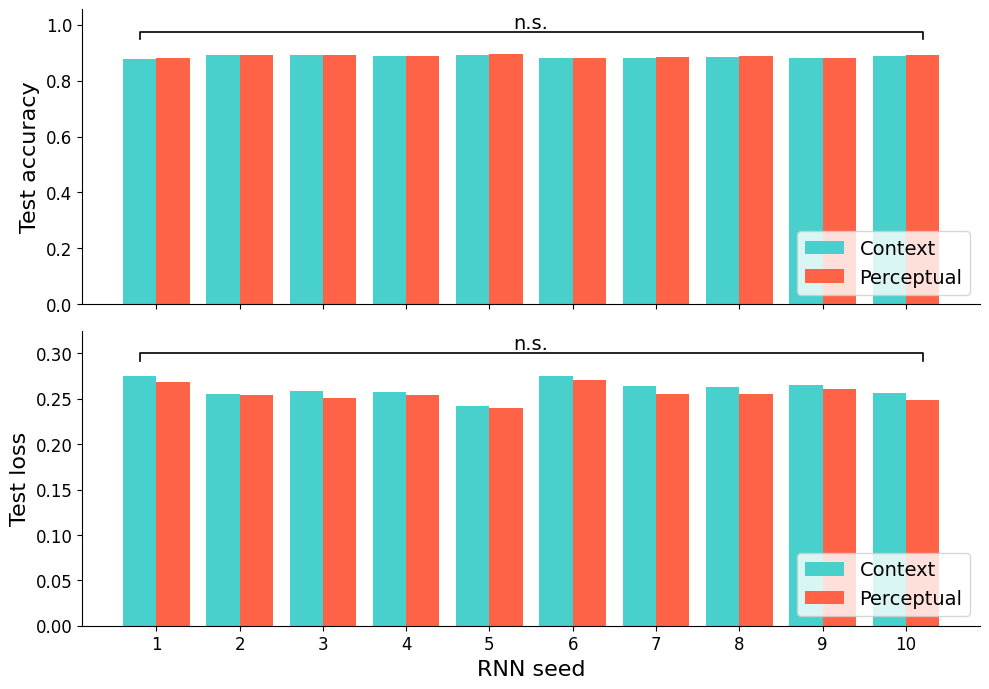

In [18]:
seeds = np.arange(1, N_SEEDS + 1)     # x positions = seed number 1..10
w = 0.4                                # bar width (two grouped bars per seed)

def annotate_sig(ax, x1, x2, p, data_top):
    """Horizontal significance bracket x1..x2 above the bars, marker via p_to_stars(p)."""
    span = data_top - ax.get_ylim()[0]
    y, h = data_top + 0.06*span, 0.03*span
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
    ax.text((x1+x2)/2, y+h, p_to_stars(p), ha='center', va='bottom', fontsize=14)
    ax.set_ylim(top=y + 4*h)   # headroom so bracket + marker are not clipped

fig, (ax_acc, ax_loss) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- top: test accuracy (context left bar, perceptual right bar) ---
ax_acc.bar(seeds - w/2, test_acc['context'],    w, color=COLOR_CONTEXT,    label='Context')
ax_acc.bar(seeds + w/2, test_acc['perceptual'], w, color=COLOR_PERCEPTUAL, label='Perceptual')
ax_acc.set_ylabel('Test accuracy')
ax_acc.legend(loc='lower right')

# --- bottom: test loss (same coloring) ---
ax_loss.bar(seeds - w/2, test_loss['context'],    w, color=COLOR_CONTEXT,    label='Context')
ax_loss.bar(seeds + w/2, test_loss['perceptual'], w, color=COLOR_PERCEPTUAL, label='Perceptual')
ax_loss.set_ylabel('Test loss')
ax_loss.set_xlabel('RNN seed')
ax_loss.set_xticks(seeds)
ax_loss.legend(loc='lower right')

# --- significance bracket (MWU context vs perceptual) on top of each panel ---
xl, xr = seeds[0] - w/2, seeds[-1] + w/2
annotate_sig(ax_acc,  xl, xr, p_acc,  max(test_acc['context'].max(),  test_acc['perceptual'].max()))
annotate_sig(ax_loss, xl, xr, p_loss, max(test_loss['context'].max(), test_loss['perceptual'].max()))

fig.tight_layout()
fig.savefig(f"{FIG_ACC_DIR}/test_accuracy_loss_bars.png", dpi=300)
plt.show()

## Figure 2: Time-resolved PID for all seeds
Compute the Gaussian MMI-PID at **every timestep** for all 10 CTRNNs of each task,
bipartition-averaged over 200 random 50/50 unit splits (same procedure as the existing
`gaussian_pid_rnn`). Cache to `all_time_PID_{context,perceptual}` shaped
`[n_seeds=10, T, n_atoms=5]` in bits (atom axis = `ATOMS`), persist to disk, then draw
one figure per seed (perceptual | context).

#### 2a. GPU-batched PID (validated against `gaussian_pid_rnn`)
The bottleneck in `gaussian_pid_rnn` is recomputing a fresh covariance for each of the
200 bipartitions at each of 115 timesteps. But at a given timestep the joint covariance
over *all* units + target is shared across bipartitions, so we compute it **once per
timestep** on the GPU and only batch the small sub-block log-determinants per split. The
bipartition sequence is generated with the *same* regularization as `gaussian_pid_rnn`, so results
match to ~1e-10 bits (checked in 2b).

#### 2b. Sanity check vs the reference implementation
Run one seed through both paths on a handful of timesteps and confirm the GPU result
matches `gaussian_pid_rnn` to within numerical noise (< 1e-6 bits). This justifies using
the fast path for all 20 CTRNNs.

In [6]:
_H = load_activations('context', '01'); _Y = load_coherences('context', '01')
_gpu = gaussian_pid_rnn_gpu(_H, _Y, n_bip=200, seed=SEED_ANALYSIS, reg=1e-5)
_ref = gaussian_pid_rnn(activations=_H, target=_Y, timestep=None, bipartitions='random',
                        n_bipartitions=200, seed=SEED_ANALYSIS, log_base=2, regularization=1e-5)
_ref_arr = np.stack([_ref['redundancy'] + _ref['unique1'] + _ref['unique2'] + _ref['synergy'],
                     _ref['redundancy'], _ref['unique1'], _ref['unique2'], _ref['synergy']], axis=1)
print(f"max |GPU - reference| over all timesteps/atoms = {np.abs(_gpu - _ref_arr).max():.2e} bits")
assert np.abs(_gpu - _ref_arr).max() < 1e-6, "GPU PID diverges from reference!"
print("OK - GPU PID reproduces gaussian_pid_rnn.")

max |GPU - reference| over all timesteps/atoms = 3.05e-10 bits
OK - GPU PID reproduces gaussian_pid_rnn.


#### 2c. Compute (or load) the cached PID arrays
For each task, run the time-resolved PID over all 10 seeds into
`all_time_PID_{task}` of shape `[n_seeds, T, 5]` (bits, atom order = `ATOMS`). If the
`.npy` caches already exist they are loaded instead of recomputed. Each array is
persisted with a JSON **sidecar** documenting axis meaning, atom order and units.

In [21]:
def compute_all_time_pid(task):
    """Time-resolved PID for all seeds of a task -> (n_seeds, T, 5) in bits."""
    out = np.zeros((N_SEEDS, TOTAL_TIMESTEPS, len(ATOMS)))
    for i, s in enumerate(SEED_IDS):
        H, Y = load_activations(task, s), load_coherences(task, s)
        out[i] = gaussian_pid_rnn_gpu(H, Y, n_bip=200, seed=SEED_ANALYSIS, reg=1e-5)
        print(f"  {task:11s} CTRNN_{s}  synergy@DECISION_T = {out[i, DECISION_T, 4]:.4f} bits")
    return out

def save_pid(arr, task):
    """Persist the array + a JSON sidecar describing its axes/atoms/units."""
    np.save(f"{PID_OUT_DIR}/{task}/all_time_PID.npy", arr)
    meta = {
        "array_file": "all_time_PID.npy",
        "shape": list(arr.shape),
        "axes": ["seed 0..9 = CTRNN_01..CTRNN_10",
                 f"timestep 0..{TOTAL_TIMESTEPS-1} ({MS_PER_STEP} ms each)",
                 "atom"],
        "atom_order": ATOMS,
        "units": "bits",
        "decision_t": DECISION_T,
        "note": ("Gaussian MMI-PID, bipartition-averaged over 200 random 50/50 unit "
                 "splits (seed=%d). total_mi = redundancy+unique1+unique2+synergy." % SEED_ANALYSIS),
    }
    with open(f"{PID_OUT_DIR}/{task}/all_time_PID_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

ctx_path = f"{PID_OUT_DIR}/context/all_time_PID.npy"
per_path = f"{PID_OUT_DIR}/perceptual/all_time_PID.npy"
if os.path.exists(ctx_path) and os.path.exists(per_path):
    all_time_PID_context    = np.load(ctx_path)      # cached: skip recomputation
    all_time_PID_perceptual = np.load(per_path)
    print("Loaded cached PID arrays:", all_time_PID_context.shape, all_time_PID_perceptual.shape)
else:
    t0 = time.time()
    print("Computing perceptual...");  all_time_PID_perceptual = compute_all_time_pid('perceptual')
    print("Computing context...");     all_time_PID_context    = compute_all_time_pid('context')
    save_pid(all_time_PID_perceptual, 'perceptual')
    save_pid(all_time_PID_context,    'context')
    print(f"Done in {time.time()-t0:.1f}s. Saved arrays + sidecars to {PID_OUT_DIR}/")

Loaded cached PID arrays: (10, 115, 5) (10, 115, 5)


#### 2d. Per-seed time-resolved PID figures
One figure per seed: **left = perceptual**, **right = context**, sharing the y-axis. All
five atoms are drawn with their distinct `ATOM_COLORS` and a labeled legend; the panel's
**task color** tints the stimulus-period shading and the axis spines so the two tasks are
identifiable without titles. Following `plot_pid_ax`, a dashed red line marks the decision
time and the stimulus window is shaded. x = Time (ms), y = Information (bits). The 20
figures are saved (not shown).

In [24]:
def plot_pid_ax(ax, pid, task_color, task_name):
    """Draw the 5 PID atoms (bits) over time (ms) on one axis, notebook-06 style."""
    t_ms = steps_to_ms(np.arange(TOTAL_TIMESTEPS))
    # atom curves: synergy & redundancy emphasized (lw=3), uniques thinner, total dotted
    ax.plot(t_ms, pid[:, 1], color=ATOM_COLORS['redundancy'], lw=3.0, label='Redundancy')
    ax.plot(t_ms, pid[:, 4], color=ATOM_COLORS['synergy'],    lw=3.0, label='Synergy')
    ax.plot(t_ms, pid[:, 2], color=ATOM_COLORS['unique1'], lw=1.5, alpha=0.8, label='Unique 1')
    ax.plot(t_ms, pid[:, 3], color=ATOM_COLORS['unique2'], lw=1.5, alpha=0.8, label='Unique 2')
    ax.plot(t_ms, pid[:, 0], color=ATOM_COLORS['total_mi'], lw=1.5, alpha=0.8, ls=':', label='Total MI')
    # decision-time marker + stimulus-period shading (tinted with the task color)
    ax.axvline(DECISION_T * MS_PER_STEP, color='red', ls='--', label='Decision time')
    ax.axvspan(STIM_START_STEP * MS_PER_STEP, DECISION_T * MS_PER_STEP,
               color=task_color, alpha=0.12)
    # task-colored spines to identify the panel's task without a title
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(task_color)
        ax.spines[side].set_linewidth(2.0)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Information (bits)')

    # subplot title = task name + seed id (e.g. "Perceptual CTRNN_01")
    ax.set_title(f"{task_name.title()} (CTRNN_{SEED_IDS[i]})")

for i, s in enumerate(SEED_IDS):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    plot_pid_ax(axL, all_time_PID_perceptual[i], COLOR_PERCEPTUAL, TASKS[0])   # left = perceptual
    plot_pid_ax(axR, all_time_PID_context[i],    COLOR_CONTEXT, TASKS[1])      # right = context
    axL.legend(loc='upper left')
    fig.tight_layout()
    fig.savefig(f"{FIG_PID_DIR}/CTRNN_{s}.png", dpi=300)
    plt.close(fig)                                                   # 20 figures -> don't show
print(f"Saved {N_SEEDS} per-seed PID figures to {FIG_PID_DIR}/")

Saved 10 per-seed PID figures to ../figures/all_time_pid/
